# QDM Bias Correction of ECMWF Seasonal Forecasts: Scientific Evaluation Report

**Domain:** Horn of Africa (3.5-14.5N, 33.5-47.5E) &nbsp;|&nbsp;
**Forecast:** ECMWF SEAS5, May-init, 183-day lead &nbsp;|&nbsp;
**Reference:** CHIRPS daily precipitation, 0.25 deg &nbsp;|&nbsp;
**Hindcast period:** 1993-2025 (33 years) &nbsp;|&nbsp;
**Method:** Per-month multiplicative Quantile Delta Mapping (QDM)

This notebook walks through the full evaluation of the QDM bias correction,
comparing the **raw ECMWF ensemble** against the **QDM-corrected ensemble**,
both scored against **CHIRPS observations**, under honest
**leave-one-year-out cross-validation** (each hindcast year is corrected
using a model trained on the other 32 years only -- never itself).

Every plot below is regenerated **live, in this notebook**, by calling the
actual plotting functions from `sbc_qdm.viz` / `sbc_qdm.verify.viz` against
the cached numeric results in `output/` and `output/evaluation/` -- so the
code block above each plot is the real code that produced it, not a
throwaway re-implementation. The only exception is the domain-pooled
ECDF/PDF in Section 3.2, which would require re-scanning the full 33-year
record (~90 minutes) to recompute live; that section shows the real source
code without re-executing it, and displays the already-rendered figure.

In [1]:
import inspect
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Image, display

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Robust to being run from the repo root or from notebooks/
_here = Path.cwd()
PROJECT_ROOT = _here if (_here / "pyproject.toml").exists() else _here.parent
OUTPUT_DIR = PROJECT_ROOT / "output"
EVAL_DIR = OUTPUT_DIR / "evaluation"
FIGURES_DIR = OUTPUT_DIR / "figures"
EVAL_FIGURES_DIR = EVAL_DIR / "figures"


def show(path: Path):
    display(Image(filename=str(path)))


def domain_means(ds: xr.Dataset, variables: list[str]) -> pd.DataFrame:
    rows = {}
    for v in variables:
        if v in ds:
            rows[v] = float(ds[v].mean(skipna=True))
    return pd.DataFrame.from_dict(rows, orient="index", columns=["domain mean"])

## 1. Cross-Validated Daily Diagnostics

The baseline diagnostics computed directly by `sbc-qdm cross-validate`:
mean bias, wet-day frequency, CRPS/CRPSS, and the ensemble rank histogram --
all pooled over the full 33-year cross-validated hindcast at daily resolution.
Regenerated here by calling `sbc_qdm.viz` directly on the cached
`loyo_diagnostics.nc`.

In [2]:
from sbc_qdm.viz import plot_bias_maps, plot_crps, plot_crpss, plot_rank_histogram, plot_wet_day_frequency

loyo = xr.open_dataset(OUTPUT_DIR / "loyo_diagnostics.nc")
domain_means(loyo, ["raw_bias", "corrected_bias", "wet_day_freq_raw", "wet_day_freq_corrected", "crps_raw", "crps_corrected", "crpss"])

,domain mean
raw_bias,0.3815
corrected_bias,-0.0310
wet_day_freq_raw,0.2527
wet_day_freq_corrected,0.1633
crps_raw,2.0400
crps_corrected,1.8437
crpss,0.1059


### 1.1 Mean bias

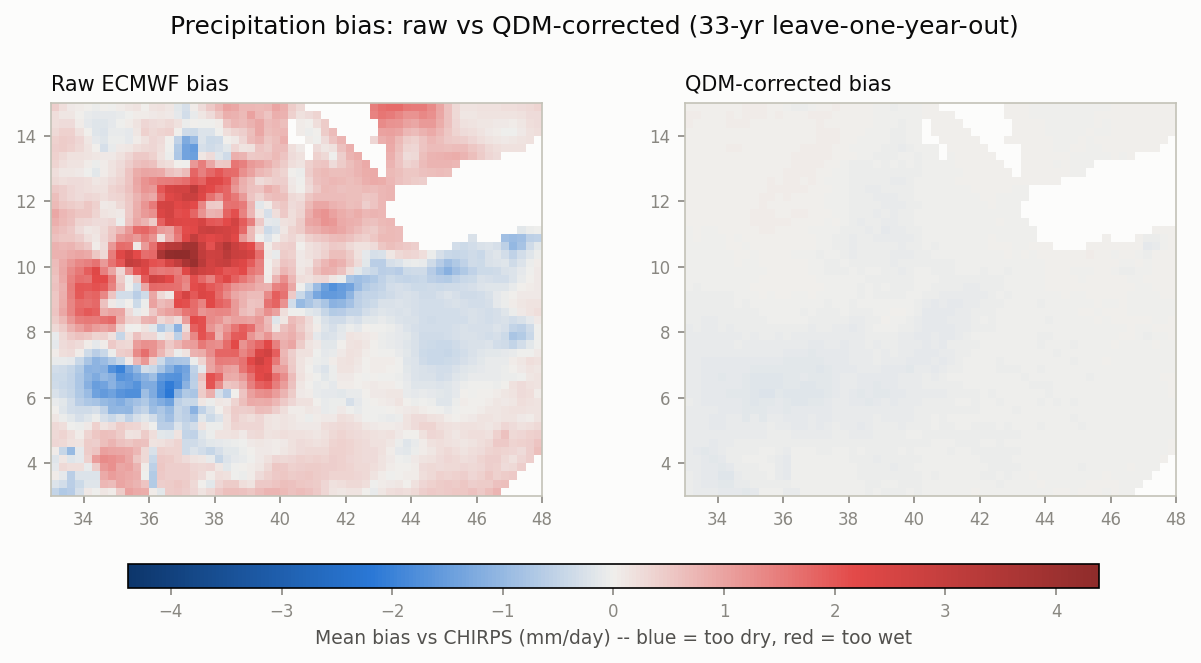

In [3]:
plot_bias_maps(loyo, FIGURES_DIR / "bias_maps.png")
show(FIGURES_DIR / "bias_maps.png")

**Reading it:** the raw forecast has a strong, spatially coherent wet bias
over the western highlands of the domain (dark red patch) with some drier
patches nearby. After correction, the map is almost uniformly near-white --
the systematic spatial bias pattern is essentially eliminated. Domain-mean
bias goes from **+0.38 mm/day** (raw) to **-0.03 mm/day** (corrected), a
~92% reduction.

### 1.2 Wet-day frequency

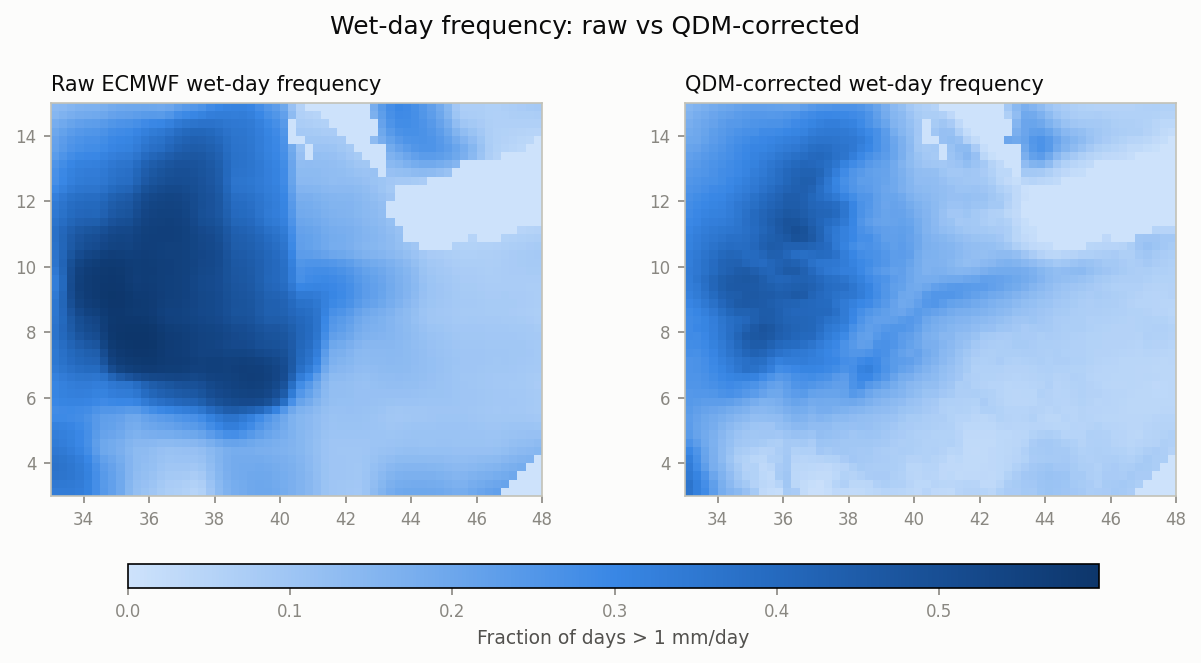

In [4]:
plot_wet_day_frequency(loyo, FIGURES_DIR / "wet_day_frequency.png")
show(FIGURES_DIR / "wet_day_frequency.png")

**Reading it:** raw ECMWF rains on **25.3%** of ensemble-member-days
domain-wide; after correction this drops to **16.3%**. This is
`xsdba.processing.adapt_freq` doing its job -- ECMWF's well-known tendency to
"drizzle" (rain too often, too lightly) is being corrected toward CHIRPS'
observed dry-day frequency.

### 1.3 CRPS and CRPS Skill Score (CRPSS)

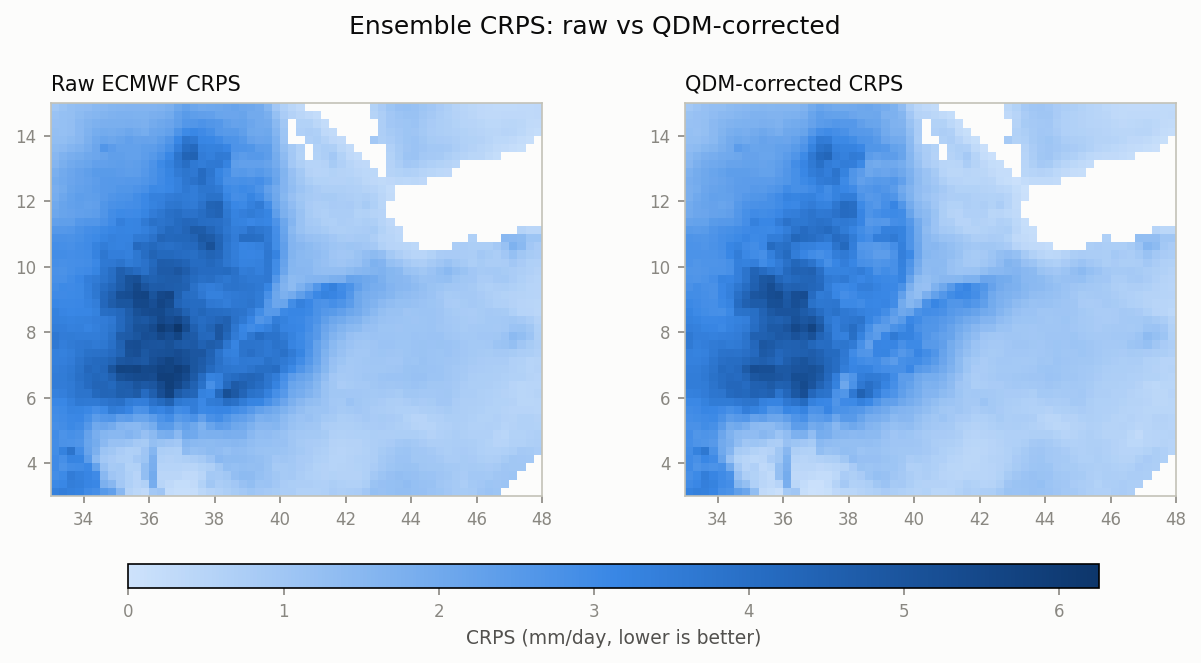

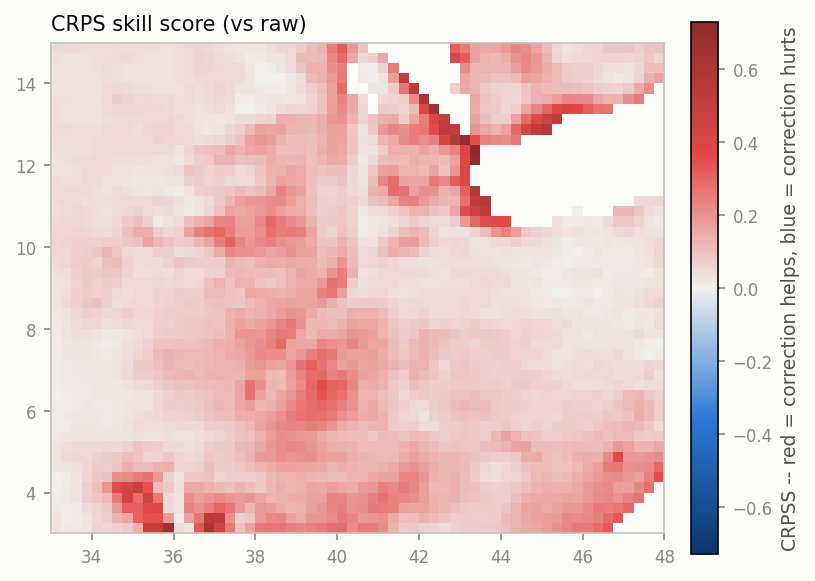

In [5]:
plot_crps(loyo, FIGURES_DIR / "crps.png")
plot_crpss(loyo, FIGURES_DIR / "crpss.png")
show(FIGURES_DIR / "crps.png")
show(FIGURES_DIR / "crpss.png")

**Reading it:** CRPS (lower is better) improves modestly domain-wide
(2.040 -> 1.844, ~10% better), and the CRPSS map is positive (red) across
nearly the entire domain -- the correction is a net improvement to ensemble
forecast quality almost everywhere, not just on average.

### 1.4 Rank histogram (ensemble calibration)

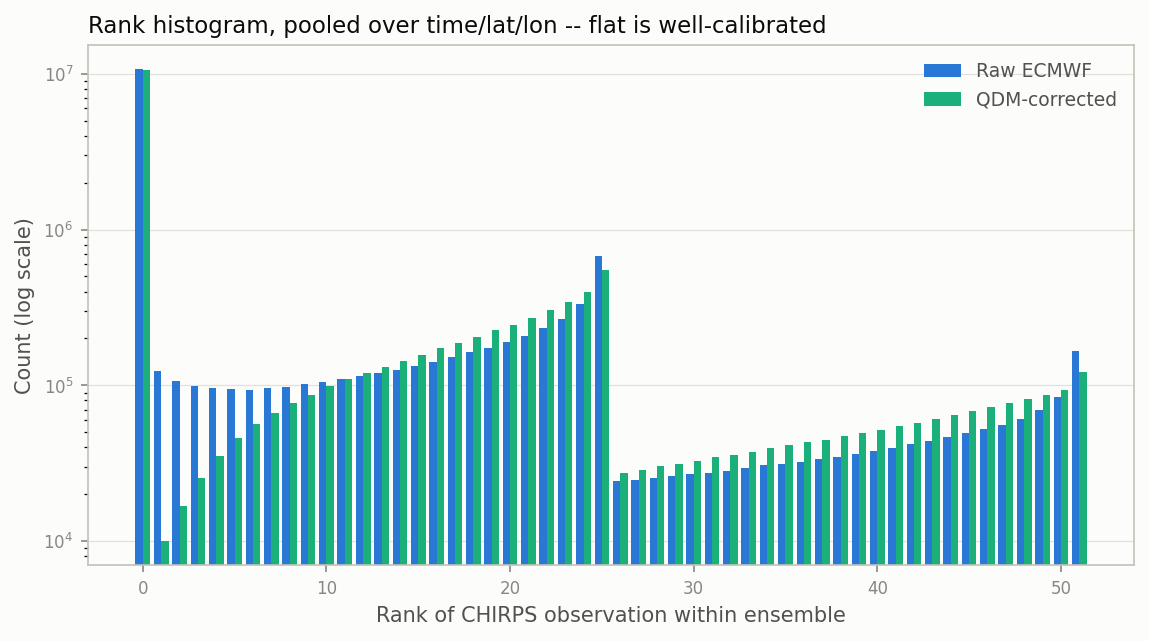

In [6]:
plot_rank_histogram(loyo, FIGURES_DIR / "rank_histogram.png")
show(FIGURES_DIR / "rank_histogram.png")

**Reading it:** log-scale y-axis, because the rank-0 bin (dry days where
CHIRPS is at or below every ensemble member) is ~40x taller than the rest --
an expected feature of zero-inflated precipitation, not miscalibration.
Note the visible break at rank 25/26: hindcast years before 2017 only have
25 ensemble members, so they can never register above rank 25 in this pooled
histogram -- a real structural artifact of the ensemble-size change, not a bug.

## 2. Daily Deterministic Metrics (Full Evaluation Suite)

Beyond the cross-validation basics: Mean Bias Error, Mean Absolute Error,
Percentage Bias, RMSE, and the standard-deviation / coefficient-of-variation
ratios, plus quantile-specific bias and ensemble spread-skill ratio.
Regenerated from the cached `daily_deterministic.nc`.

In [7]:
daily = xr.open_dataset(EVAL_DIR / "daily_deterministic.nc")
rows = []
for metric in ["mbe", "mae", "pbias", "rmse", "sd_ratio", "cv_ratio", "wet_day_freq_bias", "spread_skill_ratio"]:
    raw_name, corr_name = f"raw_{metric}", f"corrected_{metric}"
    if raw_name in daily and corr_name in daily:
        rows.append({"metric": metric, "raw": float(daily[raw_name].mean()), "corrected": float(daily[corr_name].mean())})
pd.DataFrame(rows).set_index("metric")

,raw,corrected
metric,,
mbe,0.3815,-0.0310
mae,3.0751,2.8526
pbias,31.7536,-1.5594
rmse,5.0289,4.9564
sd_ratio,0.4235,0.4226
cv_ratio,0.3281,0.4291


### 2.1 Mean Bias Error and RMSE

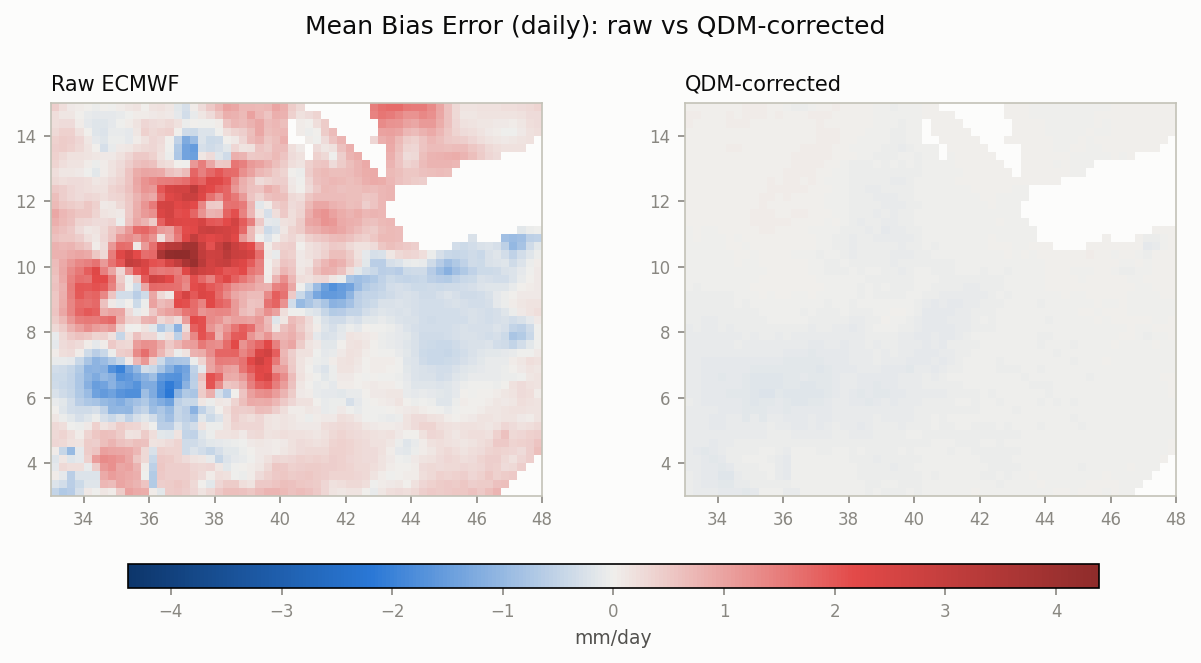

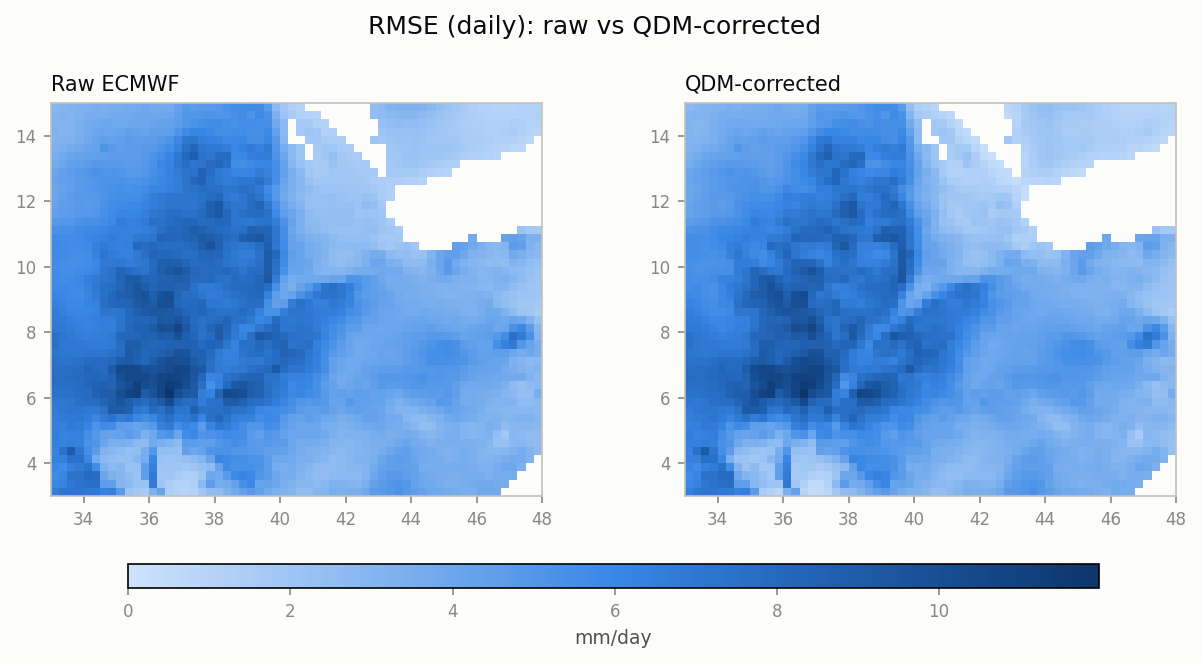

In [8]:
from sbc_qdm.verify.viz import plot_deterministic_map

plot_deterministic_map(daily["raw_mbe"], daily["corrected_mbe"], EVAL_FIGURES_DIR / "daily_mbe.png", "Mean Bias Error (daily)", "mm/day")
plot_deterministic_map(daily["raw_rmse"], daily["corrected_rmse"], EVAL_FIGURES_DIR / "daily_rmse.png", "RMSE (daily)", "mm/day", diverging=False)
show(EVAL_FIGURES_DIR / "daily_mbe.png")
show(EVAL_FIGURES_DIR / "daily_rmse.png")

**Reading it:** MBE improves the same way the cross-validation bias map did.
RMSE, however, barely moves (5.03 -> 4.96 mm/day, ~1.4%) -- because daily RMSE
is dominated by unpredictable day-to-day timing error, which a purely
*marginal* correction like QDM (it remaps each day's value independently,
using no information about neighboring days) has no mechanism to fix.

### 2.2 Percentage Bias (PBIAS)

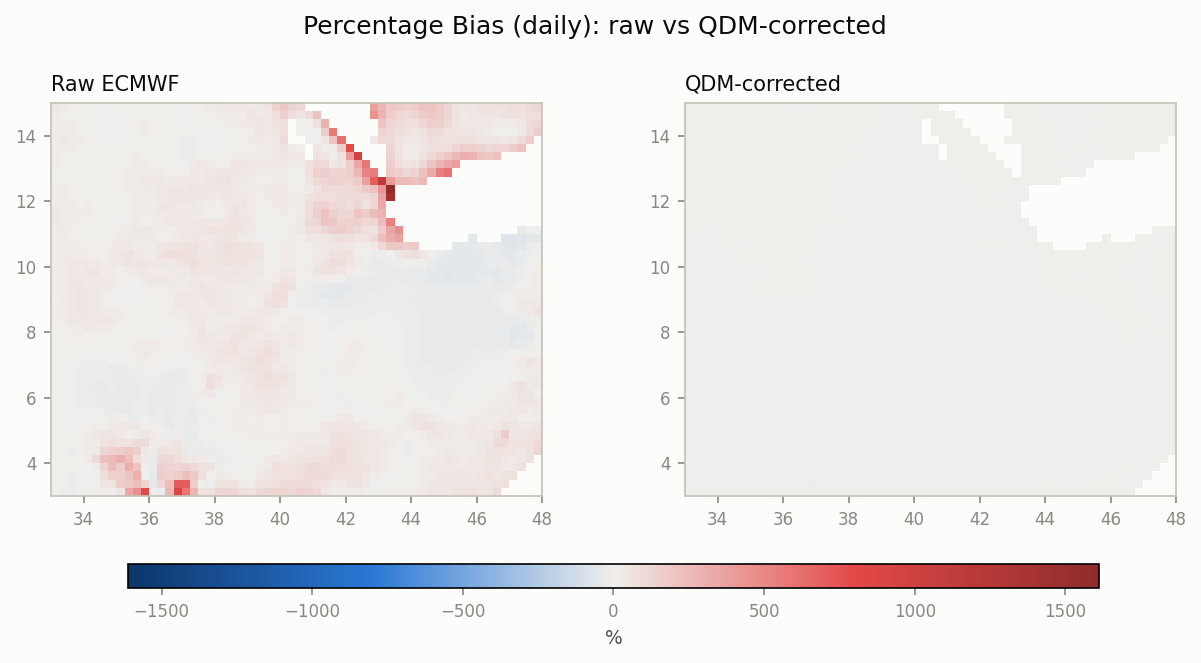

In [9]:
plot_deterministic_map(daily["raw_pbias"], daily["corrected_pbias"], EVAL_FIGURES_DIR / "daily_pbias.png", "Percentage Bias (daily)", "%")
show(EVAL_FIGURES_DIR / "daily_pbias.png")

**Reading it:** PBIAS goes from **+31.8%** (raw over-forecasts total volume
by nearly a third) to **-1.6%** -- the clearest single number showing how
thoroughly QDM fixes the systematic volume bias.

### 2.3 Quantile bias (Q10 / Q50 / Q90 / Q95)

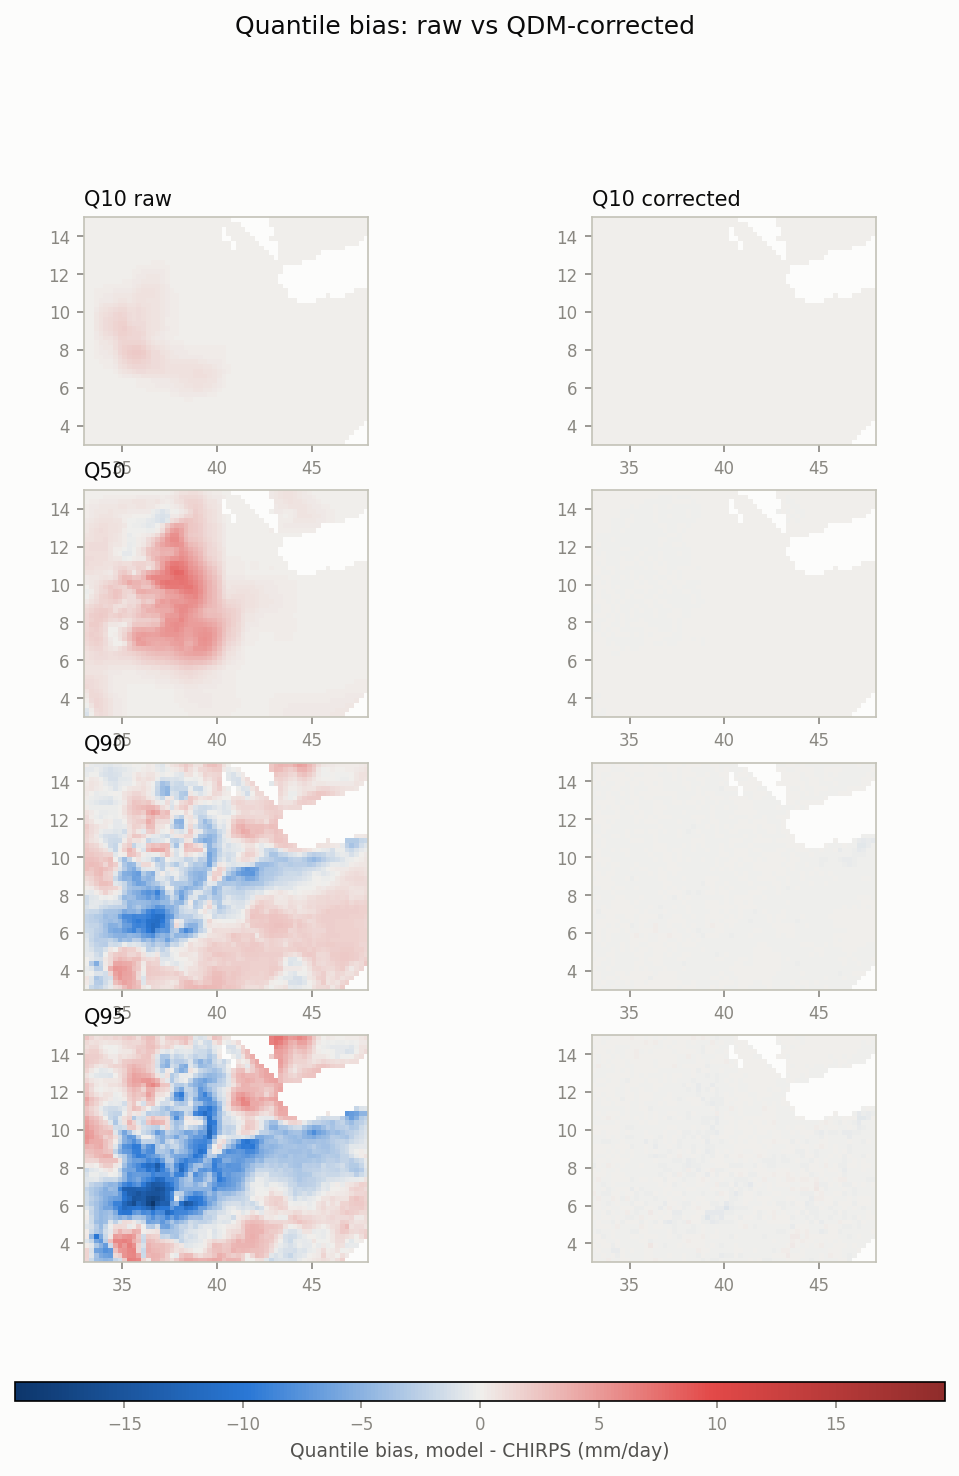

In [10]:
from sbc_qdm.verify.viz import plot_quantile_bias_grid

plot_quantile_bias_grid(daily["quantile_bias_raw"], daily["quantile_bias_corrected"], EVAL_FIGURES_DIR / "quantile_bias.png")
show(EVAL_FIGURES_DIR / "quantile_bias.png")

**Reading it:** bias at the low-to-middle quantiles (Q10, Q50) is corrected
well. At the upper quantiles (Q90, Q95) the correction is doing more work --
watch for this alongside the Q-Q plot in Section 3, which shows the same
upper-tail behavior more starkly.

### 2.4 Ensemble spread-skill ratio

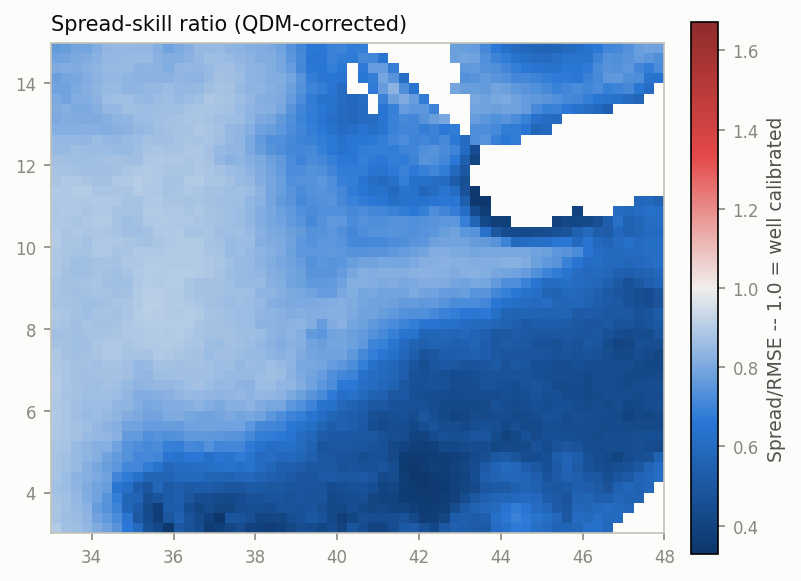

In [11]:
from sbc_qdm.verify.viz import plot_spread_skill_map

plot_spread_skill_map(daily["spread_skill_ratio_corrected"], EVAL_FIGURES_DIR / "spread_skill_ratio.png")
show(EVAL_FIGURES_DIR / "spread_skill_ratio.png")

**Reading it:** ratio of ensemble spread (std across members) to the RMSE of
the ensemble mean -- 1.0 (white) means a well-calibrated ensemble, where the
spread accurately reflects the forecast's actual uncertainty.

## 3. Distributional Similarity

Domain-pooled comparisons of the full daily precipitation distribution --
CHIRPS vs raw ECMWF vs QDM-corrected -- rather than a per-pixel summary.

### 3.1 Quantile-Quantile (Q-Q) plot

Cheap to regenerate: the sorted quantile pairs were cached in `qq_pairs.nc`
during the original (expensive) run, so replotting here doesn't need to
rescan the raw 33-year record.

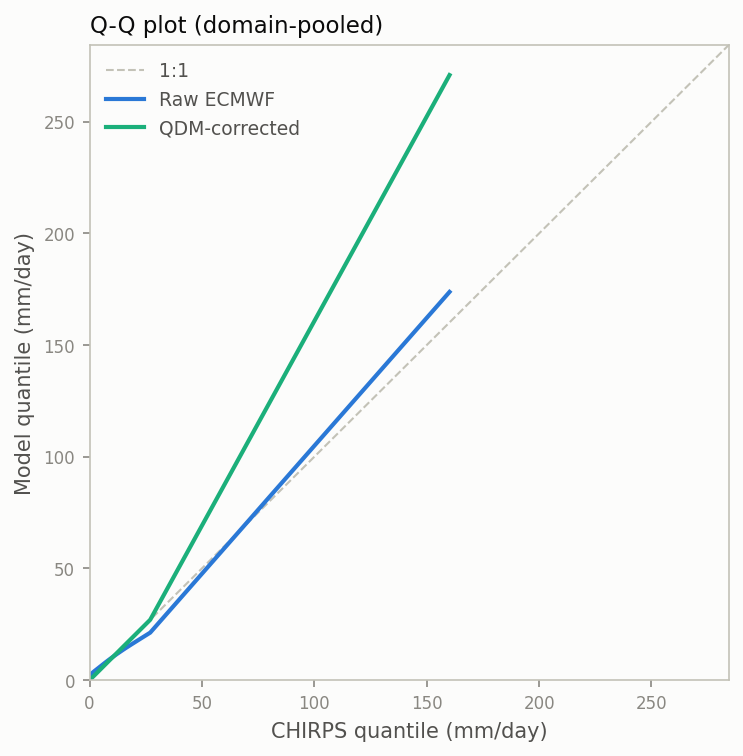

In [12]:
from sbc_qdm.verify.viz import plot_qq

qq = xr.open_dataset(EVAL_DIR / "qq_pairs.nc")
plot_qq(qq["ref"].values, qq["raw"].values, qq["corrected"].values, EVAL_FIGURES_DIR / "qq_plot.png")
show(EVAL_FIGURES_DIR / "qq_plot.png")

**Reading it -- the most important caveat in this whole report:** through
the bulk of the distribution, the corrected quantiles (green) track the 1:1
CHIRPS line closely, much better than raw (blue). But above roughly the 95th
percentile, the corrected line diverges *above* both the 1:1 line and the raw
forecast -- QDM is amplifying extreme values beyond what either the raw model
or CHIRPS itself has ever produced. This matches the elevated maximum seen in
the operational 2026 corrected forecast (257 mm/day corrected vs 123 mm/day
raw) -- **traced to an exact mechanism, not just a pattern in aggregate**,
in Section 8 below.

### 3.2 Empirical CDF and probability density

**Not re-executed here.** `dist.ecdf()`/`dist.pdf_histogram()` stream the
*entire* 33-year x 51-member x full-domain array in (lat,lon) blocks to build
a domain-pooled sample (see `verify/aggregate.py`'s `iter_spatial_blocks`) --
in the original run this took roughly 90 minutes across the 6 obs/raw/
corrected ECDF+PDF calls, and unlike the Q-Q pairs above, the underlying
curve data wasn't cached separately. The cell below shows the actual source
that produced the cached figure instead of re-running it.

In [13]:
from sbc_qdm.verify import distributions as dist
from sbc_qdm.verify.viz import plot_ecdf, plot_pdf

print(inspect.getsource(dist.ecdf))
print(inspect.getsource(dist.pdf_histogram))
print(inspect.getsource(plot_ecdf))
print(inspect.getsource(plot_pdf))

def ecdf(da: xr.DataArray, n_points: int = 200) -> tuple[np.ndarray, np.ndarray]:
    """Domain-pooled empirical CDF: (sorted_x, F(x)), subsampled to n_points."""
    sorted_vals = np.sort(_flatten_valid(da))
    n = len(sorted_vals)
    y = np.arange(1, n + 1) / n
    if n > n_points:
        idx = np.linspace(0, n - 1, n_points).astype(int)
        return sorted_vals[idx], y[idx]
    return sorted_vals, y

def pdf_histogram(da: xr.DataArray, bins: int = 60, value_range: tuple[float, float] | None = None) -> tuple[np.ndarray, np.ndarray]:
    """Domain-pooled density histogram: (bin_centers, density).

    A plain histogram rather than a KDE -- precipitation's point-mass at zero
    (dry days) would be smeared out by kernel smoothing into a misleadingly
    continuous-looking density near zero.
    """
    flat = _flatten_valid(da)
    counts, edges = np.histogram(flat, bins=bins, range=value_range, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    return centers, counts

d

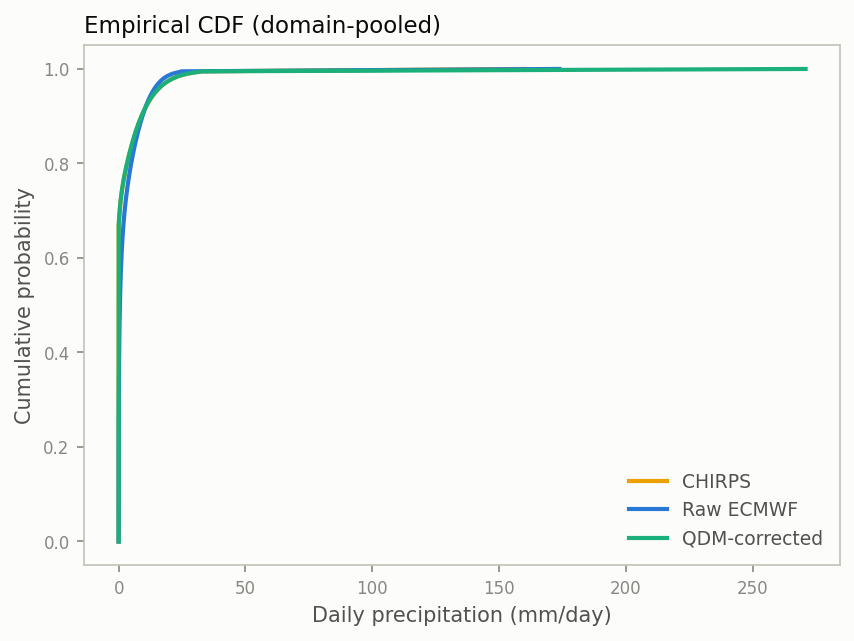

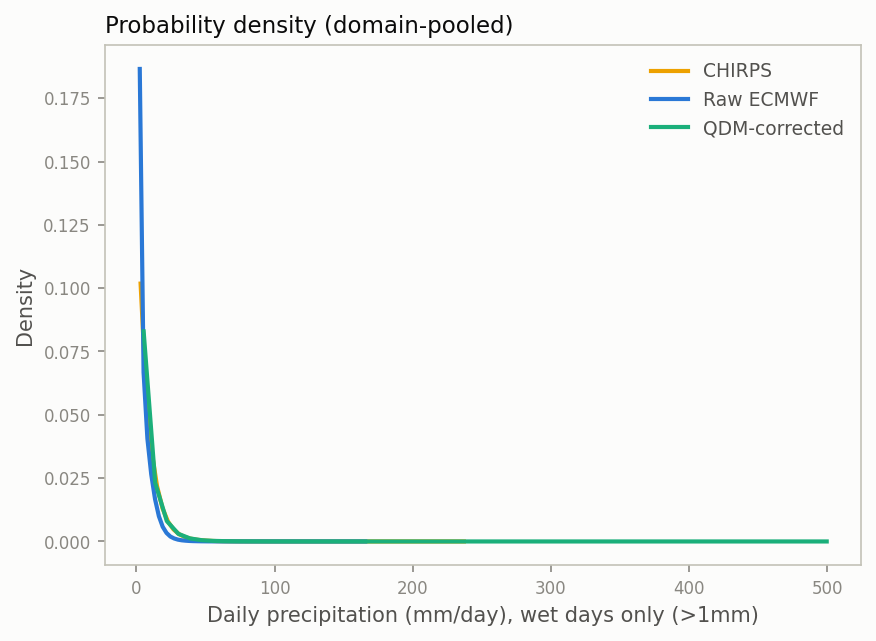

In [14]:
show(EVAL_FIGURES_DIR / "ecdf.png")
show(EVAL_FIGURES_DIR / "pdf.png")

**Reading it:** the ECDF confirms the corrected distribution (green) sits
much closer to CHIRPS (yellow) than raw (blue) does through most of its
range. The PDF (wet days only, >1mm) shows the corrected distribution's
shape converging toward CHIRPS' in the low-to-moderate rainfall range.

## 4. Wet/Dry Spell Persistence

Does the correction fix how long wet and dry spells tend to last -- not just
how much rain falls on any given day? Regenerated from the cached raw
spell-length samples (`spell_lengths.npz`) -- the expensive part (extracting
run-lengths from every pixel/member time series) already happened during
`sbc-qdm evaluate`; rebuilding the histogram from those cached arrays is a
cheap numpy operation.

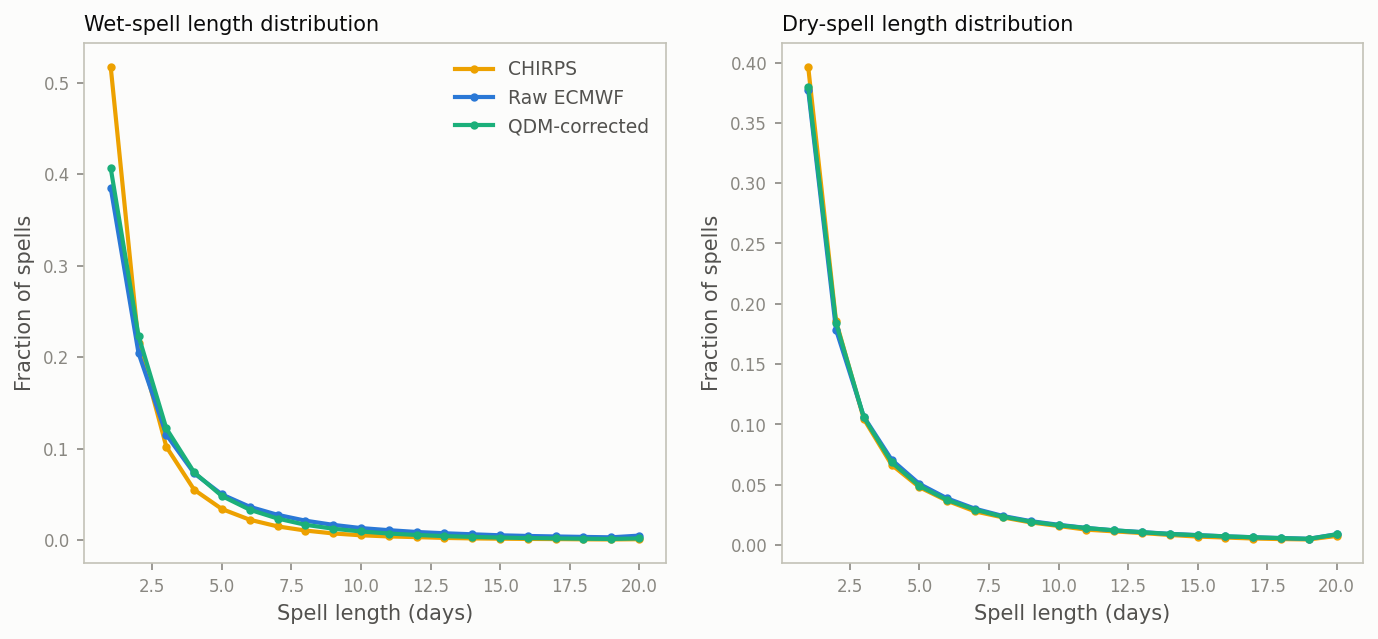

In [15]:
from sbc_qdm.verify.viz import plot_spell_distributions

spell_lengths = np.load(EVAL_DIR / "spell_lengths.npz")
plot_spell_distributions(
    spell_lengths["obs_wet"], spell_lengths["raw_wet"], spell_lengths["corrected_wet"],
    spell_lengths["obs_dry"], spell_lengths["raw_dry"], spell_lengths["corrected_dry"],
    EVAL_FIGURES_DIR / "spell_distributions.png",
)
show(EVAL_FIGURES_DIR / "spell_distributions.png")

**Reading it:** dry-spell length distributions are essentially identical
across CHIRPS, raw, and corrected -- unsurprising, since QDM barely touches
dry-day classification. More notably, **wet-spell lengths are also barely
changed by the correction**: CHIRPS shows a much sharper spike at 1-day wet
spells (52%) than either raw (39%) or corrected (41%) reproduce, meaning
both the raw and corrected forecasts still overstate the persistence of
rain events relative to reality. This is expected -- QDM corrects each day's
magnitude independently and has no mechanism to fix day-to-day sequencing --
but it's a genuine limitation worth stating plainly rather than implying the
correction fixes everything.

## 5. Spatial Performance

The complement to the per-pixel maps above: for each day, how well does the
model's *spatial pattern* match CHIRPS' spatial pattern (after removing each
pixel's own long-term climatology, so a shared wet/dry climatological
gradient doesn't inflate the score)? Regenerated from the cached
`daily_spatial_timeseries.nc` (one value per day -- small, cheap to replot).

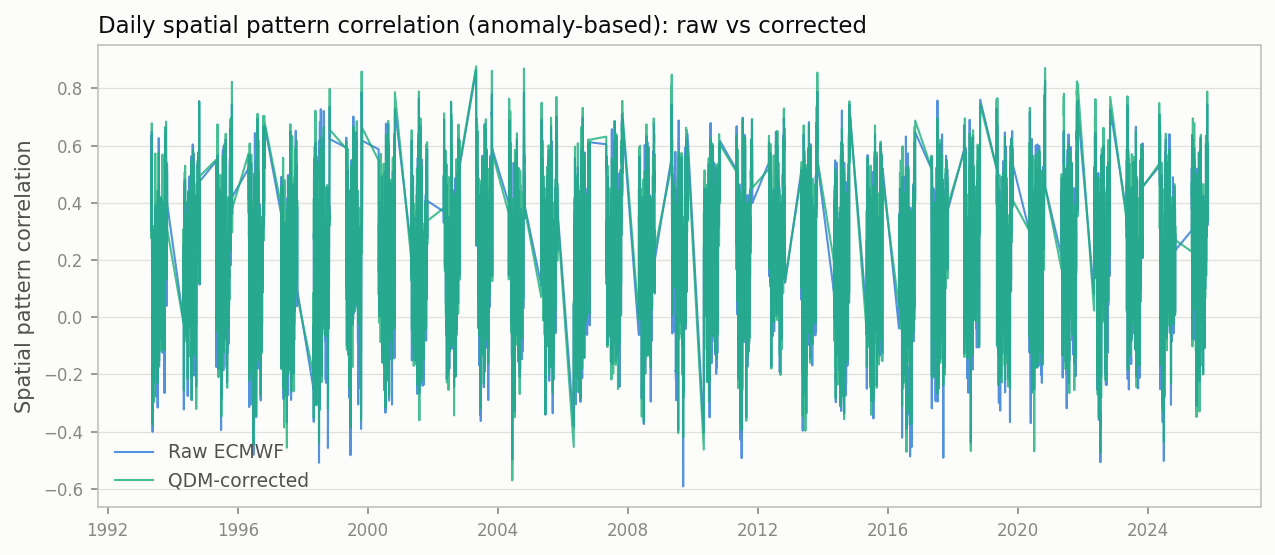

In [16]:
from sbc_qdm.verify.viz import plot_spatial_metric_timeseries

spatial_ts = xr.open_dataset(EVAL_DIR / "daily_spatial_timeseries.nc")
plot_spatial_metric_timeseries(
    spatial_ts["spatial_pattern_correlation_raw"], spatial_ts["spatial_pattern_correlation_corrected"],
    EVAL_FIGURES_DIR / "spatial_pattern_correlation.png",
    "Spatial pattern correlation", "Daily spatial pattern correlation (anomaly-based): raw vs corrected",
)
show(EVAL_FIGURES_DIR / "spatial_pattern_correlation.png")

**Reading it:** a noisy but broadly comparable time series for raw vs
corrected -- QDM operates pixel-by-pixel with no explicit spatial-consistency
term, so it isn't expected to systematically improve (or degrade) how well
the model captures the *spatial shape* of a given day's anomaly.

## 6. Deterministic Skill vs Climatology (JJAS Season Total)

Aggregating to the JJAS (June-September) seasonal total -- the core Horn of
Africa rains -- and asking: does the model beat a naive "predict the
long-term normal every year" climatology forecast? Regenerated from the
cached `jjas_deterministic_and_skill.nc`.

In [17]:
jjas = xr.open_dataset(EVAL_DIR / "jjas_deterministic_and_skill.nc")
rows = []
for metric in ["mbe", "rmse", "acc", "spearman_acc", "rmsess", "interannual_variability_ratio"]:
    raw_name, corr_name = f"raw_{metric}", f"corrected_{metric}"
    if raw_name in jjas and corr_name in jjas:
        rows.append({"metric": metric, "raw": float(jjas[raw_name].mean()), "corrected": float(jjas[corr_name].mean())})
pd.DataFrame(rows).set_index("metric")

,raw,corrected
metric,,
mbe,56.8142,-4.2220
rmse,110.1733,56.8546
acc,0.2419,0.2036
spearman_acc,0.2323,0.1956
rmsess,-2.5838,-0.1927
interannual_variability_ratio,1.1052,0.8308


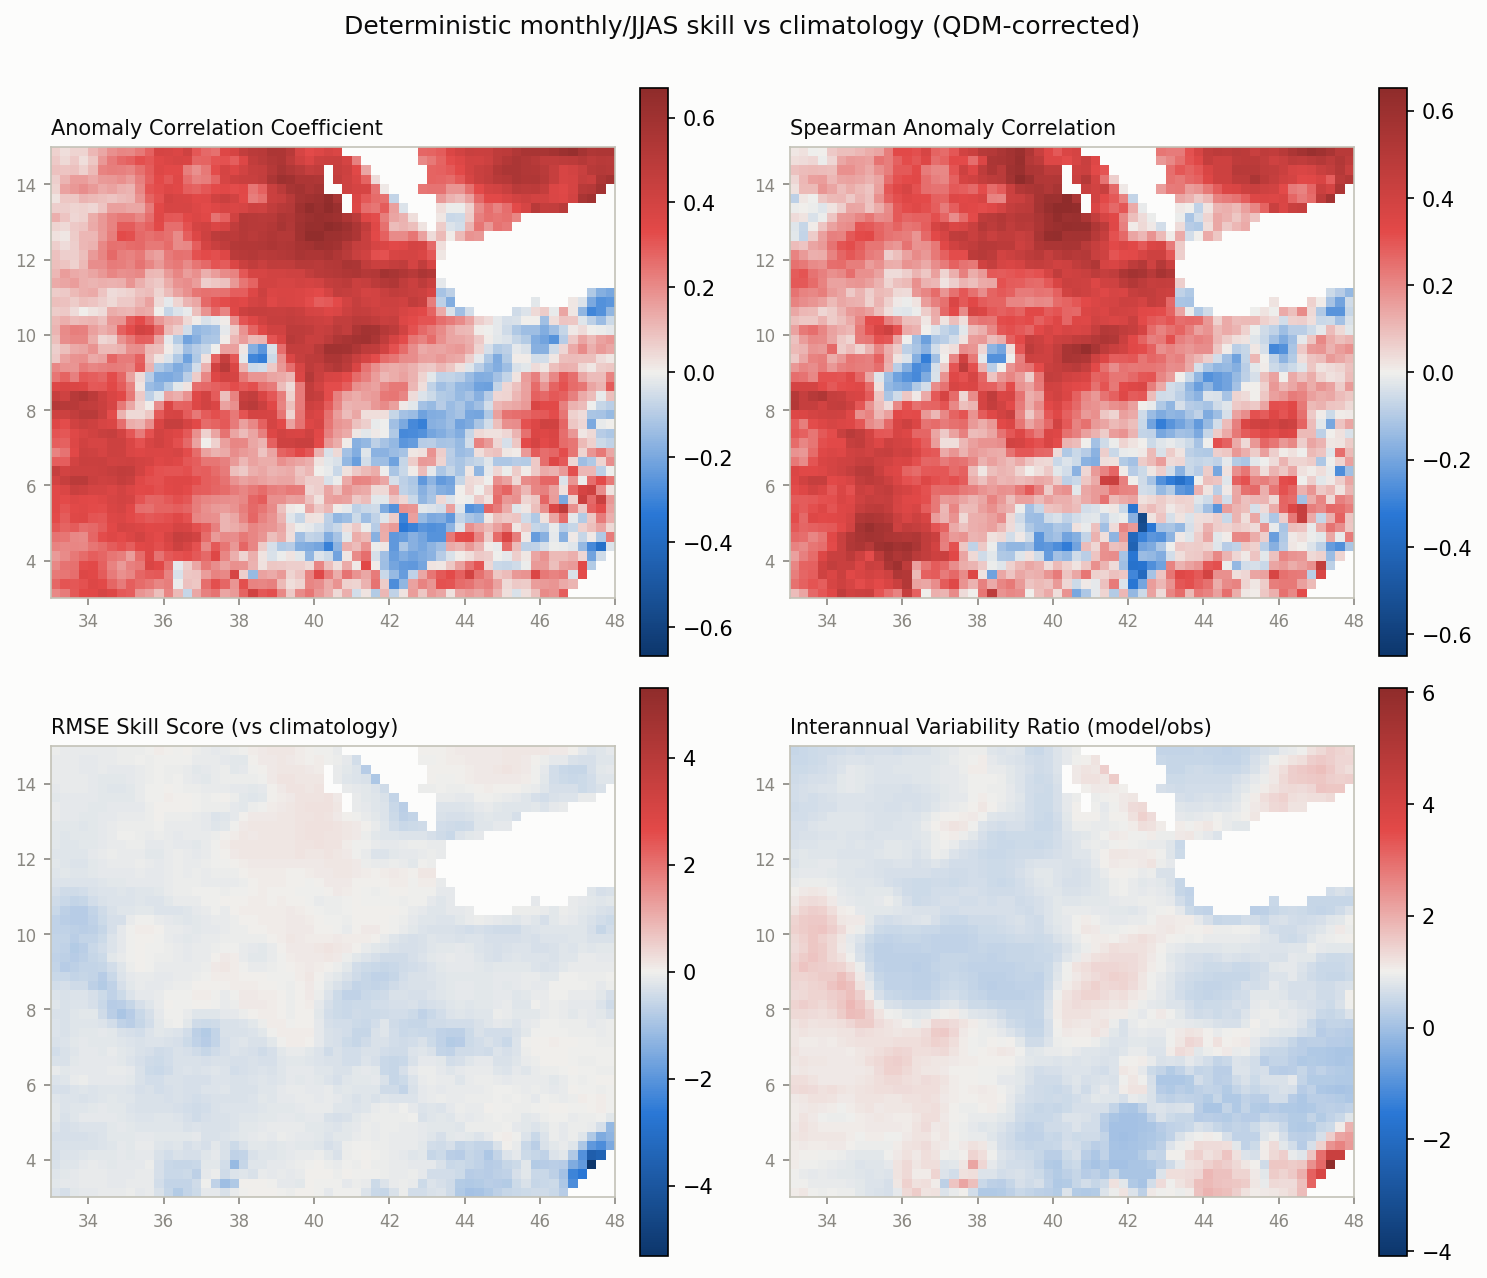

In [18]:
from sbc_qdm.verify.viz import plot_skill_maps

plot_skill_maps(
    jjas["corrected_acc"], jjas["corrected_spearman_acc"], jjas["corrected_rmsess"], jjas["corrected_interannual_variability_ratio"],
    EVAL_FIGURES_DIR / "jjas_skill_maps.png",
)
show(EVAL_FIGURES_DIR / "jjas_skill_maps.png")

**Reading it:** JJAS-total RMSE improves dramatically (110.2mm -> 56.9mm,
~48%) -- at this aggregated scale, random day-to-day noise cancels out
through summation and the systematic bias fix dominates, unlike daily RMSE
in Section 2 which barely moved. RMSE Skill Score (vs climatology) goes from
deeply negative (-2.58, much worse than climatology) to only slightly
negative (-0.19, nearly on par) -- a large improvement, though not yet fully
"skillful" against naive climatology.

The Anomaly Correlation Coefficient (ACC), however, tells a different story:
it **drops slightly** after correction (0.242 -> 0.204), as does the
interannual variability ratio moving further from 1.0 (1.105 -> 0.831). QDM
targets the marginal distribution, not year-to-year rank correlation or
interannual spread directly, so it's not guaranteed -- and here didn't
happen -- to improve every skill dimension simultaneously.

## 7. Probabilistic Ensemble Skill (Tercile-Category Forecasts)

Scoring the ensemble as a probabilistic forecast of below-normal /
near-normal / above-normal JJAS-total categories, defined from CHIRPS' own
climatological terciles -- the standard WMO/IRI convention for seasonal
forecast verification. Regenerated from the cached `jjas_probabilistic.nc`.

In [19]:
prob = xr.open_dataset(EVAL_DIR / "jjas_probabilistic.nc")
rows = [
    {"metric": "RPSS", "raw": float(prob["raw_rpss"].mean()), "corrected": float(prob["corrected_rpss"].mean())},
    {"metric": "BSS (above-normal)", "raw": float(prob["raw_bss"].sel(category="above").mean()), "corrected": float(prob["corrected_bss"].sel(category="above").mean())},
    {"metric": "ROC skill (above-normal)", "raw": float(prob["raw_roc_skill_score"].sel(category="above").mean()), "corrected": float(prob["corrected_roc_skill_score"].sel(category="above").mean())},
    {"metric": "CRPS", "raw": float(prob["crps_raw"].mean()), "corrected": float(prob["crps_corrected"].mean())},
]
pd.DataFrame(rows).set_index("metric")

,raw,corrected
metric,,
RPSS,-0.2636,-0.0553
BSS (above-normal),-0.2180,-0.0305
ROC skill (above-normal),0.2456,0.2423
CRPS,72.8147,32.7320


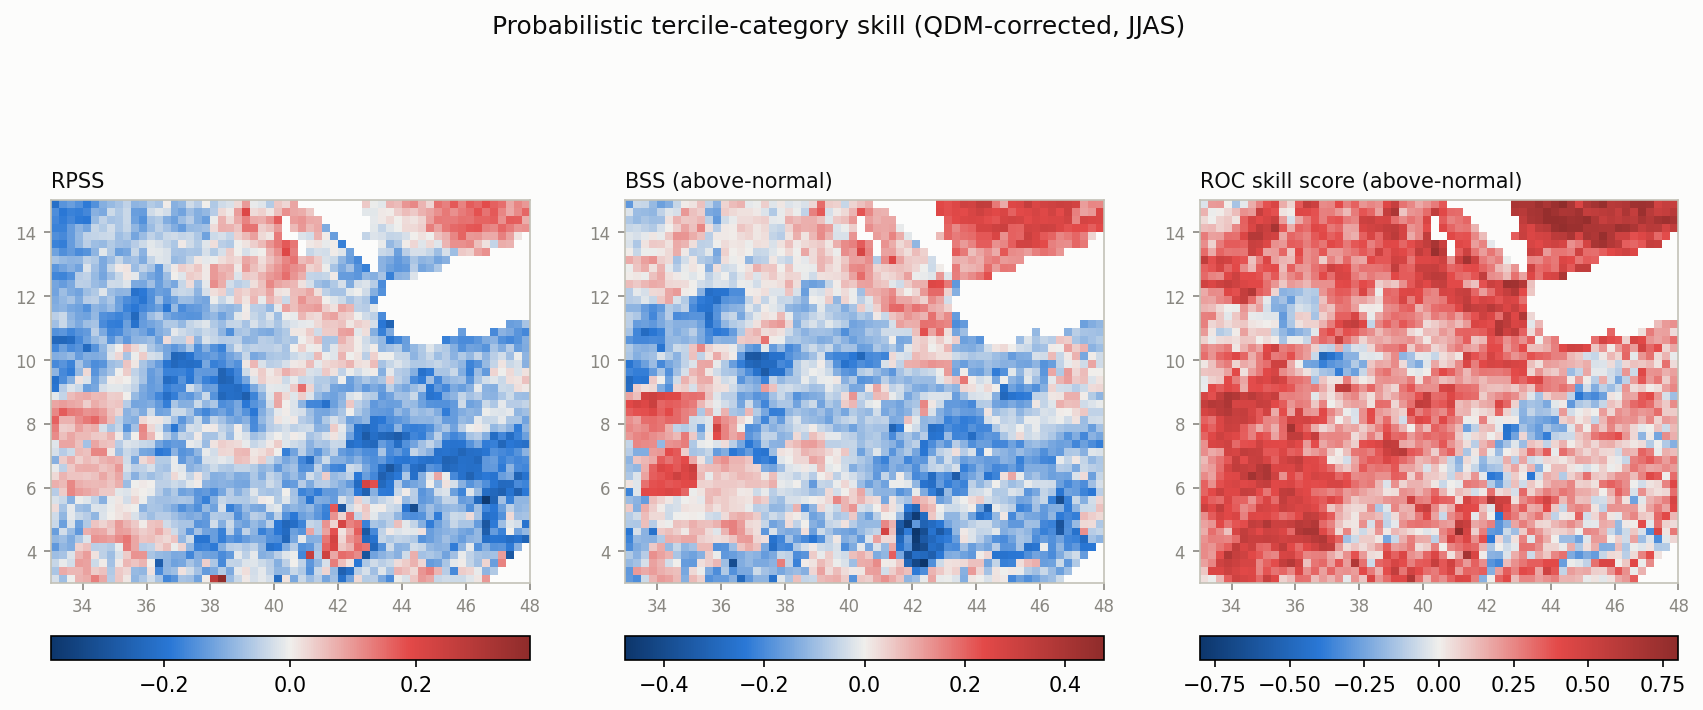

In [20]:
from sbc_qdm.verify.viz import plot_probabilistic_skill_maps

plot_probabilistic_skill_maps(
    prob["corrected_rpss"], prob["corrected_bss"].sel(category="above"), prob["corrected_roc_skill_score"].sel(category="above"),
    EVAL_FIGURES_DIR / "jjas_probabilistic_skill.png",
)
show(EVAL_FIGURES_DIR / "jjas_probabilistic_skill.png")

**Reading it -- the clearest methodological insight in this report:** RPSS
and BSS both improve substantially after correction (RPSS: -0.264 -> -0.055;
BSS: -0.218 -> -0.031), while ROC skill score is essentially **unchanged**
(0.246 -> 0.242). This is textbook-consistent: RPSS/BSS are sensitive to
probability *calibration* (is the forecast probability the right magnitude?),
which QDM directly improves by fixing the marginal distribution. ROC skill
measures *discrimination* (can the ensemble rank which years will be
above-normal, regardless of the probability's absolute scale?) -- a
monotonic quantile transform preserves rank order within each training fold,
so discrimination ability is mostly untouched by this kind of correction.

Spatially, RPSS/BSS are positive (red) in the northeast of the domain but
negative (blue) through the central-south, while ROC skill is strongly
positive almost everywhere -- the ensemble discriminates above-normal
seasons reasonably well nearly everywhere, but its absolute probability
calibration is still poor in the central/southern part of the domain even
where discrimination is fine.

### 7.1 Reliability diagram (above-normal event)

The RPSS/BSS/ROC arrays above were cached, but not the underlying per-year
tercile probabilities the reliability diagram needs -- this cell recomputes
just those (JJAS-aggregating the cached `loyo_corrected.nc` and re-deriving
CHIRPS' tercile thresholds), a couple of minutes of work, not the ~90-minute
cost of the ECDF/PDF section.

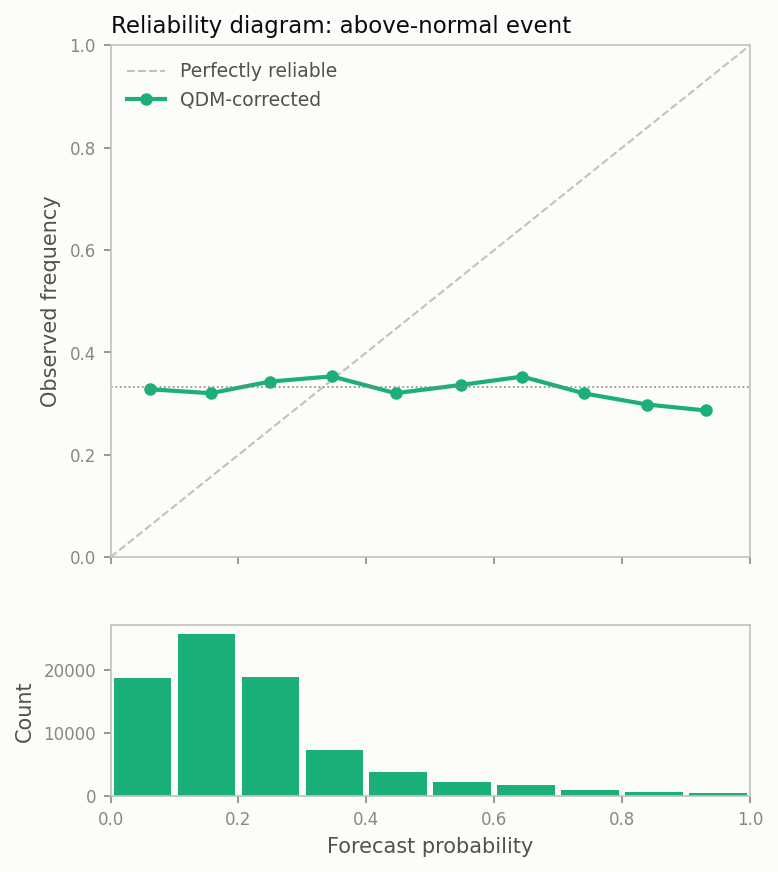

In [21]:
from sbc_qdm.config import load_config
from sbc_qdm.io import load_chirps_reference
from sbc_qdm.preprocess import build_land_mask
from sbc_qdm.verify import aggregate as agg
from sbc_qdm.verify import calibration as cal
from sbc_qdm.verify import probabilistic as vprob
from sbc_qdm.verify.viz import plot_reliability_diagram

cfg = load_config()
chirps_masked = load_chirps_reference(cfg)
chirps_masked = chirps_masked.where(build_land_mask(chirps_masked))
corrected_full = xr.open_dataarray(OUTPUT_DIR / "loyo_corrected.nc", chunks={"lat": 10, "lon": 10})
ref_full = chirps_masked.sel(time=corrected_full["time"])

ref_j = agg.jjas_totals(ref_full)
corrected_j = agg.jjas_totals(corrected_full)
thresholds = agg.tercile_thresholds(ref_j)
obs_category = agg.tercile_category(ref_j, thresholds)
corrected_probs = agg.ensemble_tercile_probabilities(corrected_j, thresholds)

obs_ind_above = vprob.obs_indicator_for_category(obs_category, "above")
fmean, ofreq, counts = cal.reliability_diagram_data(corrected_probs.sel(category="above"), obs_ind_above)
plot_reliability_diagram(fmean, ofreq, counts, EVAL_FIGURES_DIR / "reliability_diagram.png")
show(EVAL_FIGURES_DIR / "reliability_diagram.png")

**Reading it:** the corrected ensemble's reliability curve sits well below
the 1:1 perfectly-reliable line for most forecast-probability bins -- when
the ensemble says "70-80% chance of above-normal", the event actually occurs
noticeably less often than that domain/year-pooled. Combined with the mixed
RPSS/BSS spatial pattern above, this is consistent evidence that calibration,
while improved over the raw forecast, is not yet fully reliable everywhere.

## 8. Operational 2026 Forecast: JJAS Seasonal Total

Everything above is retrospective hindcast skill. This section shows the
actual deployable output of the pipeline: ECMWF's live 2026 forecast, raw
and QDM-corrected (trained on the *entire* 33-year hindcast, no year held
out -- see `sbc-qdm apply`), aggregated to the JJAS seasonal total and
averaged across ensemble members.

In [22]:
from sbc_qdm.config import load_config
from sbc_qdm.io import load_chirps_reference
from sbc_qdm.preprocess import build_land_mask
from sbc_qdm.pipeline import prepare_target_year
from sbc_qdm.verify import aggregate as agg
from sbc_qdm.verify.viz import plot_deterministic_map

cfg = load_config()
chirps = load_chirps_reference(cfg)
mask = build_land_mask(chirps)

raw_2026 = prepare_target_year(cfg, chirps, mask, 2026)
corrected_2026 = xr.open_dataarray(OUTPUT_DIR / "corrected_2026.nc")

raw_2026_jjas = agg.jjas_totals(raw_2026).mean("realization").squeeze("year", drop=True)
corrected_2026_jjas = agg.jjas_totals(corrected_2026).mean("realization").squeeze("year", drop=True)

pd.DataFrame(
    {
        "raw": [float(raw_2026_jjas.mean()), float(raw_2026_jjas.min()), float(raw_2026_jjas.max())],
        "corrected": [float(corrected_2026_jjas.mean()), float(corrected_2026_jjas.min()), float(corrected_2026_jjas.max())],
    },
    index=["domain mean (mm)", "min (mm)", "max (mm)"],
)

,raw,corrected
domain mean (mm),319.0016,256.6214
min (mm),6.4231,0.0093
max (mm),"1,432.3036","1,305.4371"


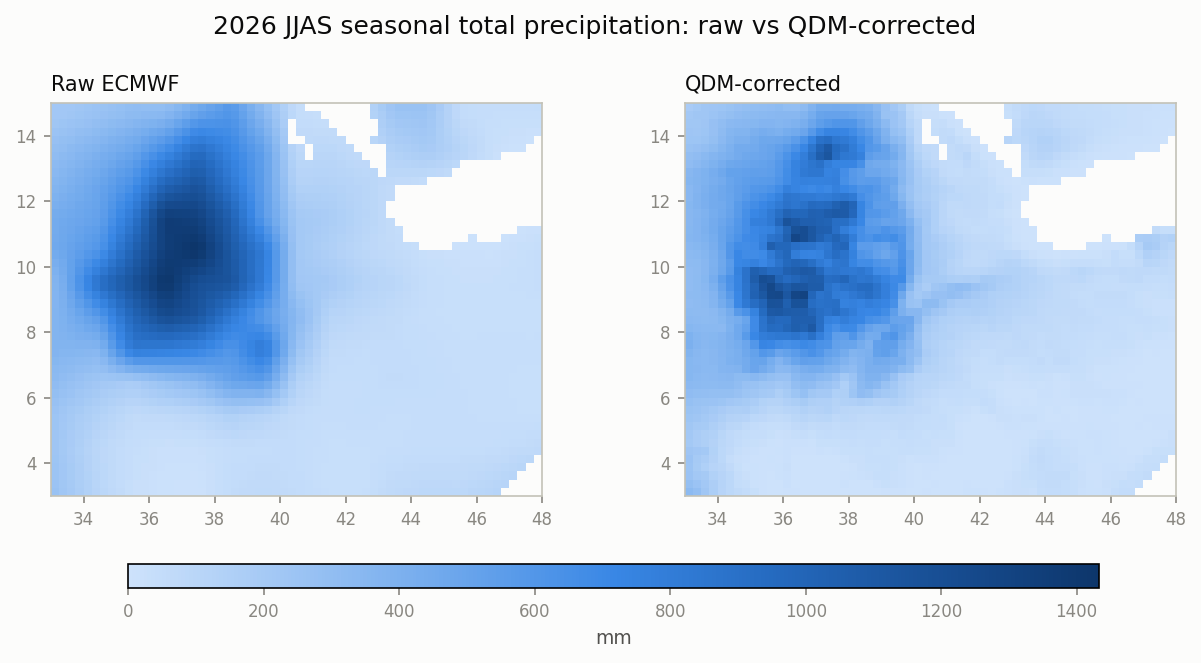

In [23]:
plot_deterministic_map(
    raw_2026_jjas, corrected_2026_jjas,
    EVAL_FIGURES_DIR / "jjas_2026_total.png",
    "2026 JJAS seasonal total precipitation", "mm", diverging=False,
)
show(EVAL_FIGURES_DIR / "jjas_2026_total.png")

**Reading it:** the correction pulls the 2026 JJAS-total ensemble mean down
domain-wide -- **319.0mm (raw) -> 256.6mm (corrected)**, a ~20% reduction --
consistent with raw ECMWF's wet bias found throughout this report. The
spatial pattern (wetter northwest, drier southeast) is preserved by the
correction, as expected for a per-pixel method. Note the corrected maximum
here (1305mm) is actually *lower* than raw's (1432mm) for this specific
year/ensemble-mean view -- this doesn't contradict the upper-tail
amplification seen in the pooled daily Q-Q plot (Section 3.1): that finding
is about the *pooled daily distribution* across all pixels/years/members,
while this is a single year's ensemble-mean seasonal total, a different
aggregation entirely. Don't over-generalize between the two.

### 8.1 Investigating the daily extreme-value amplification

Section 3.1's Q-Q plot flagged that corrected quantiles exceed both raw and
CHIRPS above ~Q95. Rather than leave that as an aggregate pattern, here's the
exact mechanism, traced to the single daily value driving `corrected_2026`'s
**257 mm/day maximum** (see `output/qdm_trained.nc`, produced by
`sbc-qdm train`, for the per-pixel/month adjustment factors used below).

In [24]:
# locate the exact pixel/day/member behind corrected_2026's maximum
flat_idx = int(corrected_2026.argmax())
idx = np.unravel_index(flat_idx, corrected_2026.shape)
extreme = {corrected_2026.dims[i]: corrected_2026[corrected_2026.dims[i]].values[idx[i]] for i in range(len(idx))}
print("extreme value location:", extreme, "=", float(corrected_2026.max()), "mm")

raw_val = float(raw_2026.sel(lat=extreme["lat"], lon=extreme["lon"], method="nearest").sel(time=extreme["time"], realization=extreme["realization"]))
print("raw value at that exact location:", raw_val, "mm")

raw_day = raw_2026.sel(lat=extreme["lat"], lon=extreme["lon"], method="nearest").sel(time=extreme["time"])
print("full raw ensemble at that pixel/day (25 members):", np.sort(raw_day.values))

extreme value location: {'lat': np.float32(7.875), 'lon': np.float32(47.125), 'time': np.datetime64('2026-10-22T00:00:00.000000000'), 'realization': np.int64(22)} = 257.4703674316406 mm
raw value at that exact location: 54.47578430175781 mm
full raw ensemble at that pixel/day (25 members): [0.00000000e+00 0.00000000e+00 0.00000000e+00 2.86102295e-02
 2.86102295e-02 4.57763672e-02 1.22070312e-01 1.33514404e-01
 2.02178955e-01 2.91824341e-01 4.32968140e-01 5.11169434e-01
 6.12258911e-01 6.48498535e-01 9.40322876e-01 1.42097473e+00
 2.20680237e+00 3.25012207e+00 7.66754150e+00 9.00077820e+00
 1.05476379e+01 1.15661621e+01 1.77669525e+01 2.07366943e+01
 5.44757843e+01]


In [25]:
# the trained quantile-mapping curve for this pixel/month
qdm_trained = xr.open_dataset(OUTPUT_DIR / "qdm_trained.nc")
month = pd.Timestamp(extreme["time"]).month
af_pixel = qdm_trained["af"].sel(month=month, lat=extreme["lat"], lon=extreme["lon"], method="nearest")
hist_q_pixel = qdm_trained["hist_q"].sel(month=month, lat=extreme["lat"], lon=extreme["lon"], method="nearest")

print("top 3 quantile nodes:", af_pixel["quantiles"].values[-3:])
print("af at those nodes:   ", af_pixel.values[-3:])
print("hist_q (mm) at those nodes:", hist_q_pixel.values[-3:])
print()
top_af = float(af_pixel.isel(quantiles=-1))
top_hist_q = float(hist_q_pixel.isel(quantiles=-1))
print(f"raw value {raw_val:.1f}mm exceeds the top training quantile node ({top_hist_q:.1f}mm at tau=0.99)")
print(f"-> clamped to tau=0.99, af={top_af:.3f} -> predicted corrected = {raw_val:.1f} * {top_af:.3f} = {raw_val*top_af:.1f}mm")

top 3 quantile nodes: [0.95 0.97 0.99]
af at those nodes:    [4.64079156 4.7033464  4.72632669]
hist_q (mm) at those nodes: [ 8.64562988 11.44439697 17.32227951]

raw value 54.5mm exceeds the top training quantile node (17.3mm at tau=0.99)
-> clamped to tau=0.99, af=4.726 -> predicted corrected = 54.5 * 4.726 = 257.5mm


**The mechanism, precisely:** at this pixel (Ethiopia's Somali Region, near
the Somalia border) in October, CHIRPS' own historical 99th-percentile daily
rainfall is **~82mm**, while raw ECMWF's 99th percentile at the same
pixel/month is only **~17mm** -- a genuine, large model bias at the extreme
tail (raw ECMWF's own historical max there, 61mm, is under half of CHIRPS'
historical max of 134mm). That's a real deficiency worth correcting.

The problem is *how* the correction is applied beyond the last quantile node:
`numpy.interp` (used to map a raw value to its quantile, then that quantile to
an adjustment factor) clamps rather than extrapolates, so **any** raw value
above the 99th-percentile training threshold gets the *same* flat ~4.7x
factor, regardless of how far into the tail it sits. Ensemble member 22's raw
forecast for this pixel/day happened to be an outlier within its own
ensemble (54.5mm, vs a next-highest member around 21mm) -- itself already
over 3x the model's typical 99th-percentile value. Applying the flat 4.7x
factor to that already-unusual value, rather than a smoothly graduated one,
produces 257mm -- nearly double even CHIRPS' own 134mm historical maximum at
this pixel.

**Practical takeaway:** the correction is reproducing a real, large model
bias at the tail, not fabricating one -- but the flat-beyond-the-last-node
behavior means it can overshoot the observational record itself when applied
to an already-extreme raw ensemble member.

### 8.2 Testing the fix: extra quantile nodes concentrated in the tail

`qdm.py`'s `evaluation_quantiles()` now adds extra nodes just below 1.0
(`config/domain.yaml`'s `qdm.tail_quantiles`: 0.995/0.998/0.999/0.9995) on
top of the 50 equally-spaced nodes, so the mapping has more room to graduate
through the tail instead of going flat right after 0.99. Retraining on a
small spatial subset around the exact pixel from Section 8.1 tests whether
it actually helps.

In [26]:
# retrain just this small neighborhood with the new (tail-extended) quantile grid
from sbc_qdm.pipeline import prepare_hindcast as _prepare_hindcast_for_fix
from sbc_qdm.qdm import train_qdm

_, _, ref_full_for_fix, hist_full_for_fix = _prepare_hindcast_for_fix(cfg)
subset_lat = slice(extreme["lat"] - 0.5, extreme["lat"] + 0.7)
subset_lon = slice(extreme["lon"] - 0.7, extreme["lon"] + 0.5)
fixed_trained = train_qdm(
    ref_full_for_fix.sel(lat=subset_lat, lon=subset_lon),
    hist_full_for_fix.sel(lat=subset_lat, lon=subset_lon),
    cfg,
)
fixed_af, fixed_hist_q = fixed_trained[month]
fixed_af_pixel = fixed_af.sel(lat=extreme["lat"], lon=extreme["lon"], method="nearest")
fixed_hist_q_pixel = fixed_hist_q.sel(lat=extreme["lat"], lon=extreme["lon"], method="nearest")

print("quantile nodes (top 8):", fixed_af_pixel["quantiles"].values[-8:])
print("af (top 8 nodes):     ", fixed_af_pixel.values[-8:])
print("hist_q mm (top 8 nodes):", fixed_hist_q_pixel.values[-8:])

new_tau = float(np.interp(raw_val, fixed_hist_q_pixel.values, fixed_af_pixel["quantiles"].values))
new_factor = float(np.interp(new_tau, fixed_af_pixel["quantiles"].values, fixed_af_pixel.values))
new_corrected = raw_val * new_factor
print()
print(f"raw value {raw_val:.2f}mm -> tau={new_tau:.5f} -> factor={new_factor:.3f} -> NEW corrected = {new_corrected:.2f}mm")
print(f"(previously, without the fix: {raw_val*top_af:.2f}mm; CHIRPS historical max at this pixel/month: 133.5mm)")

quantile nodes (top 8): [0.93   0.95   0.97   0.99   0.995  0.998  0.999  0.9995]
af (top 8 nodes):      [4.47320828 4.64079156 4.7033464  4.72632669 5.15137089 4.30804686
 3.65424694 3.29724253]
hist_q mm (top 8 nodes): [ 6.93702698  8.64562988 11.44439697 17.32227951 22.0318985  28.92697144
 35.0826416  39.68392563]

raw value 54.48mm -> tau=0.99950 -> factor=3.297 -> NEW corrected = 179.62mm
(previously, without the fix: 257.47mm; CHIRPS historical max at this pixel/month: 133.5mm)


**Reading it -- a genuine but partial improvement, not a full fix:** the
same raw value (54.5mm) now maps to **~180mm** instead of 257mm, a ~30%
reduction, and closer to CHIRPS' own 133.5mm historical maximum -- but still
above it. Looking at why: 54.5mm still exceeds the *extended* grid's top
node (~40mm at tau=0.9995), so `numpy.interp` still clamps -- just further
out. Extra tail nodes shrink the problem but don't eliminate it for a raw
value extreme enough to exceed even the extended empirical range, as this
one still does. The `af` values are also visibly non-monotonic in the last
few nodes (a spike at 0.995, then declining) -- genuine sampling noise, since
the most extreme quantiles are defined by only a handful of pooled samples.

A complete fix would need genuine tail extrapolation (e.g. fitting a
parametric tail distribution beyond the last empirical quantile) rather than
just adding more empirical nodes -- a bigger modeling decision than this
change, and not implemented here. Note also that `config/domain.yaml`'s
`qdm.extrapolation: constant` field is currently descriptive only -- the
clamping behavior comes from `numpy.interp`'s hardcoded default, not from
that field actually being read anywhere in the code.

**This fix changes the trained model.** The full 33-year cross-validation,
the 2026 operational forecast, and this notebook's own Sections 1-7 were
**not** automatically re-run with the new quantile grid (a multi-hour
undertaking) -- the numbers and figures throughout the rest of this notebook
still reflect the original 50-node grid unless a full re-run has since
happened.

## 9. Month-by-Month Comparison vs Climatology (2026)

Breaking the JJAS aggregate in Section 8 apart by individual calendar month
(May-Oct), and adding the 1993-2025 CHIRPS climatological normal for
context: is each month of the 2026 forecast wetter or drier than usual, and
does the correction change that answer?

In [27]:
raw_2026_m = agg.monthly_totals(raw_2026).mean("realization").squeeze("year", drop=True)
corrected_2026_m = agg.monthly_totals(corrected_2026).mean("realization").squeeze("year", drop=True)

# `chirps` (masked, all 33 years x 12 calendar months) was already loaded in Section 8
chirps_m = agg.monthly_totals(chirps)
clim_m = agg.climatology(chirps_m).sel(month=raw_2026_m["month"].values)

rows = []
for m in sorted(int(x) for x in raw_2026_m["month"].values):
    rows.append(
        {
            "month": m,
            "raw (mm)": float(raw_2026_m.sel(month=m).mean()),
            "corrected (mm)": float(corrected_2026_m.sel(month=m).mean()),
            "climatology (mm)": float(clim_m.sel(month=m).mean()),
        }
    )
pd.DataFrame(rows).set_index("month")

,raw (mm),corrected (mm),climatology (mm)
month,,,
5,58.3420,55.6780,76.7604
6,49.7552,41.2021,60.0781
7,92.4862,75.7903,98.4849
8,98.4768,77.8118,104.6614
9,78.2834,61.8168,71.6530
10,100.5282,94.6116,70.0443


### 9.1 Raw vs corrected vs climatology, each month

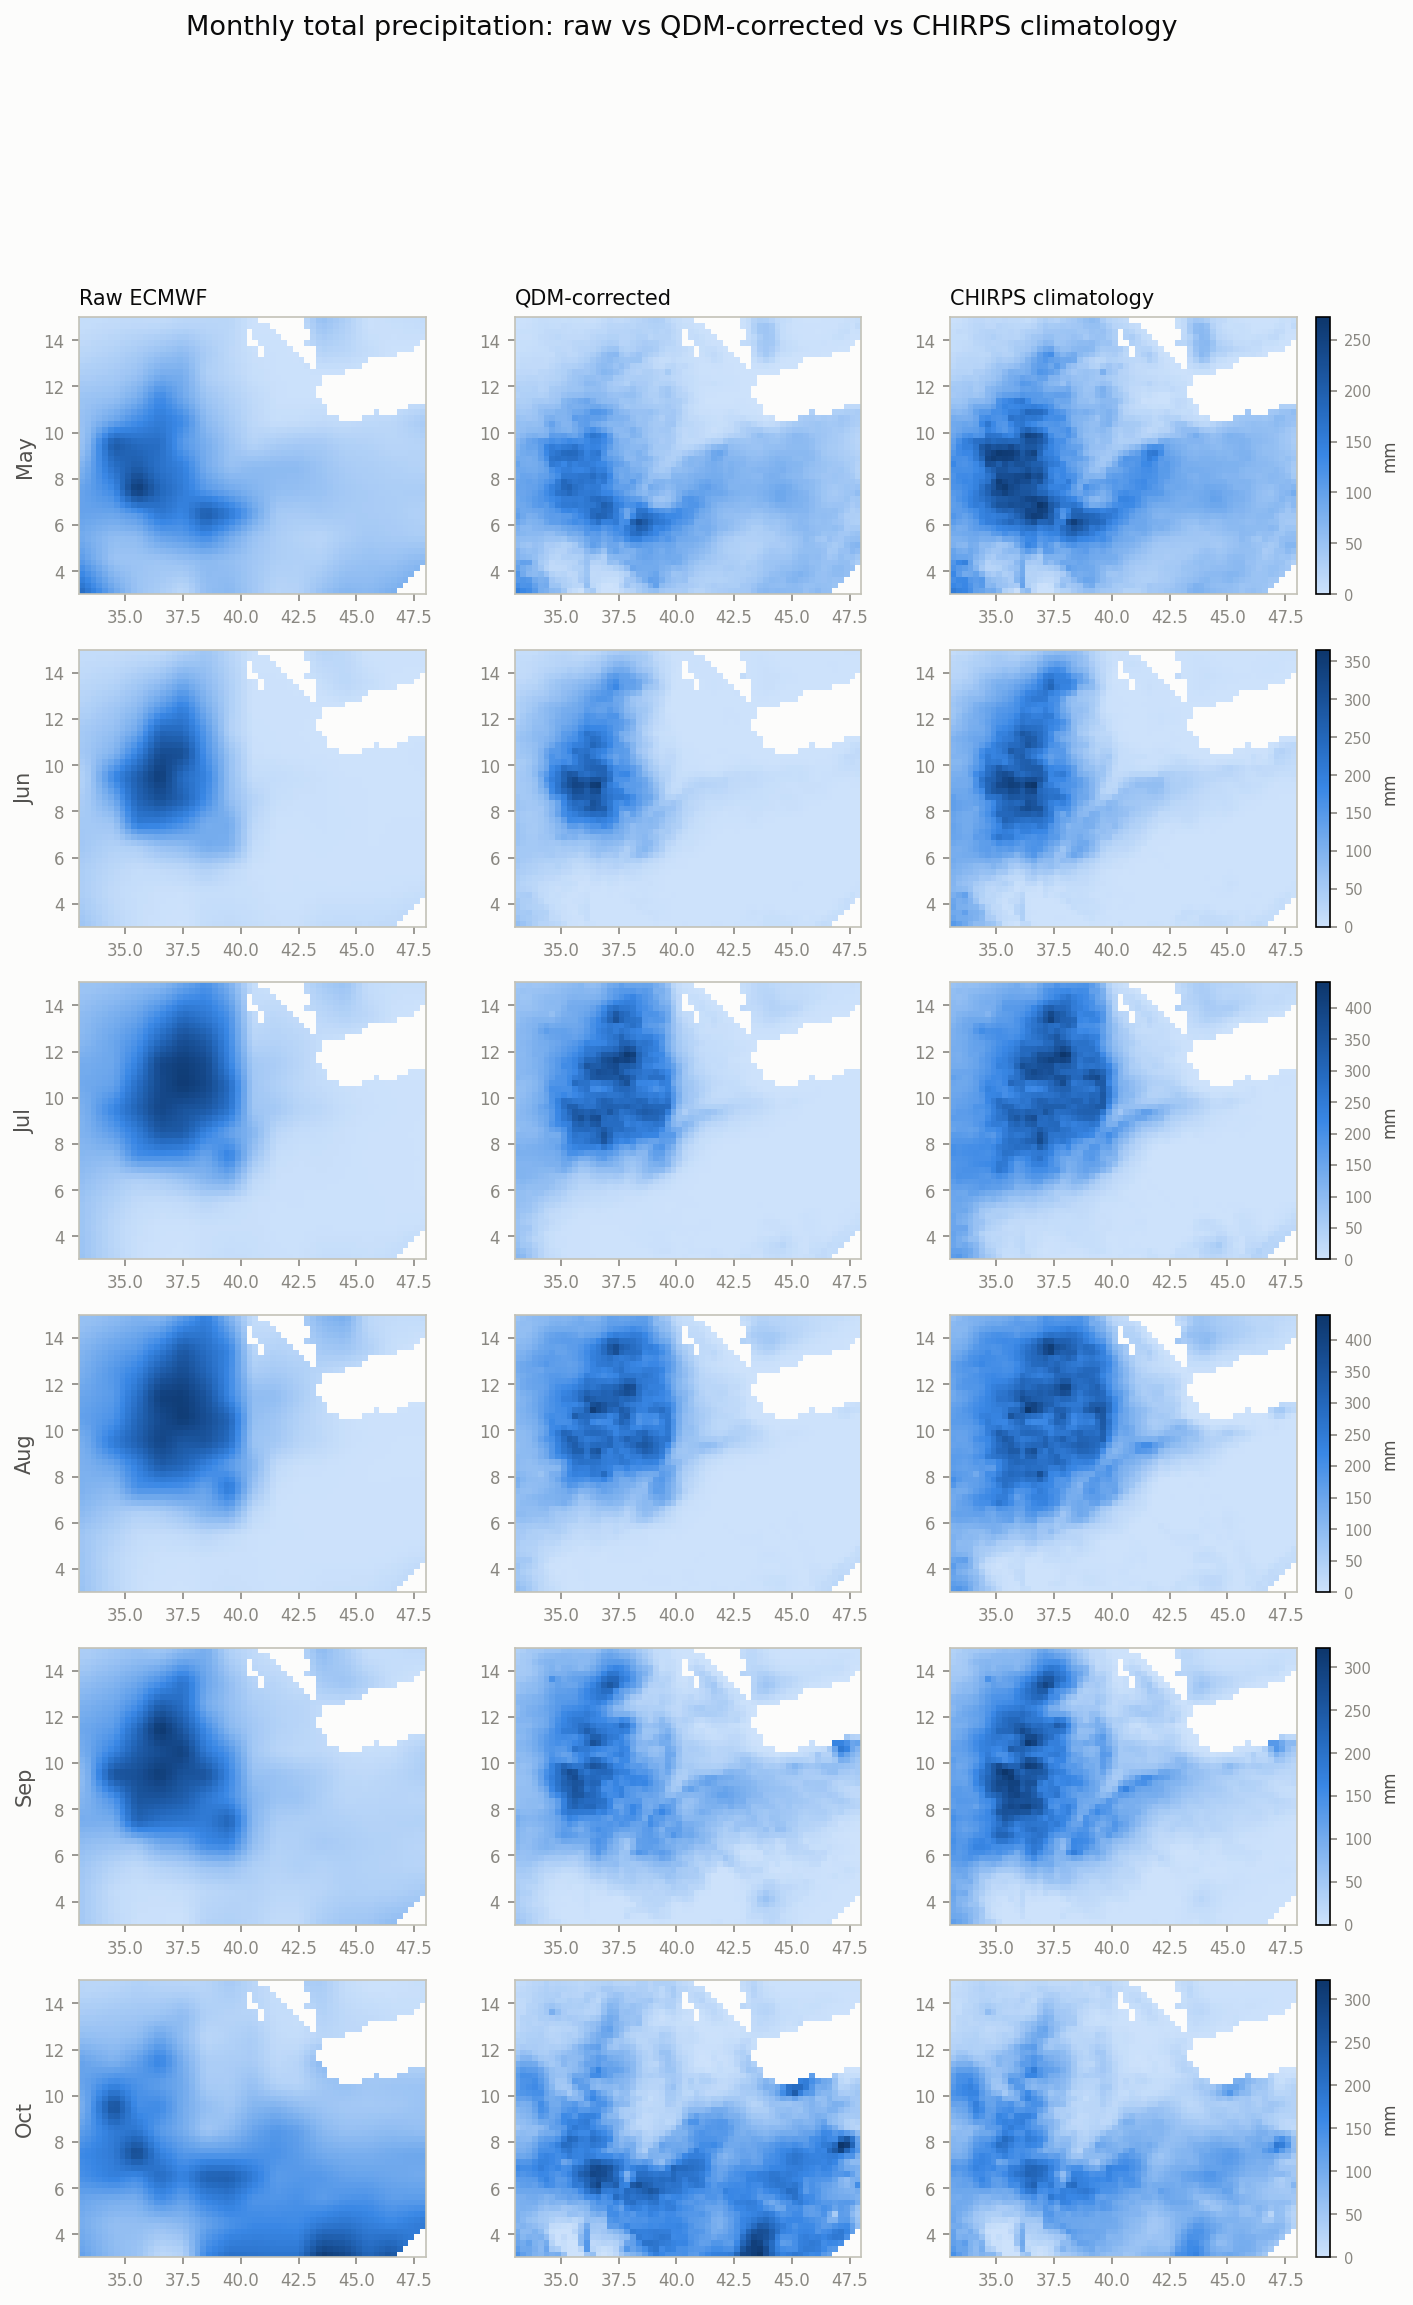

In [28]:
from sbc_qdm.verify.viz import plot_monthly_comparison_grid

plot_monthly_comparison_grid(raw_2026_m, corrected_2026_m, clim_m, EVAL_FIGURES_DIR / "monthly_2026_comparison.png")
show(EVAL_FIGURES_DIR / "monthly_2026_comparison.png")

**Reading it:** domain-mean totals put 2026 below climatology for May-Aug
(e.g. Aug: 98.5mm raw / 77.8mm corrected vs 104.7mm normal), roughly at
normal in September, and clearly above it in October (100.5mm raw / 94.6mm
corrected vs 70.0mm normal). Visually, the corrected panels also show much
finer spatial texture than raw's smoother, single-blob pattern -- closer to
the texture CHIRPS' climatology itself has, not just a magnitude fix.

### 9.2 Anomaly vs climatology: raw vs corrected

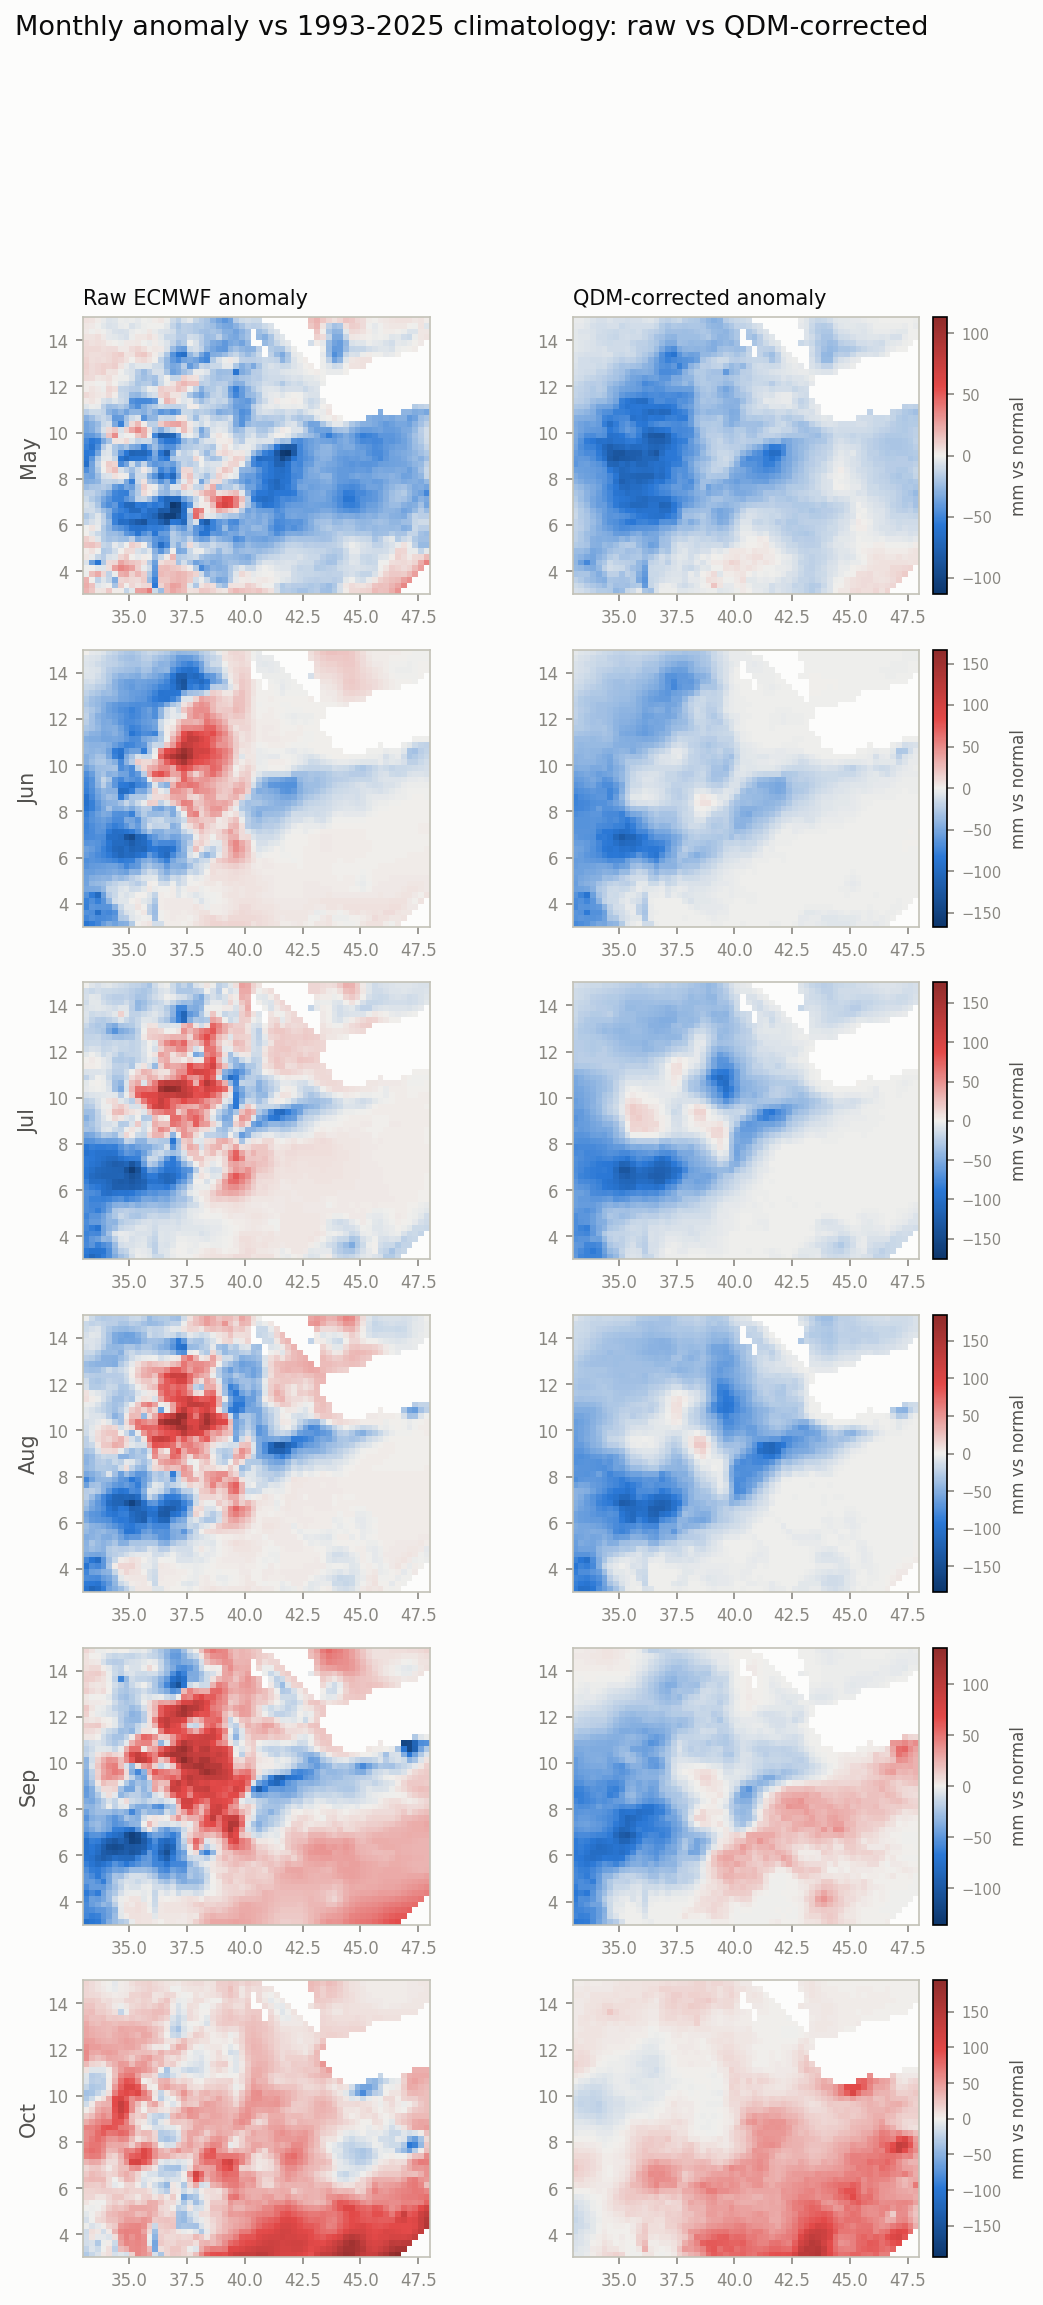

In [29]:
from sbc_qdm.verify.viz import plot_monthly_anomaly_grid

plot_monthly_anomaly_grid(raw_2026_m, corrected_2026_m, clim_m, EVAL_FIGURES_DIR / "monthly_2026_anomaly.png")
show(EVAL_FIGURES_DIR / "monthly_2026_anomaly.png")

**Reading it -- the most notable finding in this section:** for Jun/Jul/Aug,
raw ECMWF shows a strong *positive* (wetter-than-normal) anomaly in the
central-north of the domain -- but the corrected forecast shows that exact
same region as a *negative* (drier-than-normal) anomaly. This isn't just the
correction toning the signal down; it **flips the sign**. This makes sense
in context: that region is exactly where Section 1.1's bias map showed
raw ECMWF's largest systematic wet bias. Once QDM removes that systematic
bias, what's left of the "wet" signal in the raw forecast turns out to have
been mostly the model's own bias, not a genuine anomaly -- so the corrected
outlook for the core rainy months in that region is actually **drier than
normal**, the opposite conclusion an operational user would draw from the
raw forecast alone. September and October show broader agreement between
raw and corrected on the sign of the anomaly (both wetter-than-normal in the
south by October), though the corrected field is again spatially finer and
more muted in the northeast.

## 10. Summary

**What QDM fixes well:**
- Systematic mean bias, at every temporal scale (daily PBIAS +32% -> -1.6%;
  JJAS-total RMSE cut ~48%; JJAS CRPS cut ~55%, CRPSS +0.38)
- Wet-day over-frequency ("drizzle" bias): 25.3% -> 16.3% of days
- Probability calibration for tercile-category forecasts (RPSS, BSS)

**What it doesn't fix -- by design, since it's a purely marginal correction:**
- Daily RMSE (dominated by unpredictable timing error, ~1.4% improvement only)
- Ensemble-mean daily variance and tercile-discrimination (ROC skill) --
  essentially unchanged before/after
- Anomaly correlation (ACC) -- actually drops slightly (0.242 -> 0.204)
- Wet/dry spell persistence -- barely changed; CHIRPS' sharper 1-day wet-spell
  peak is not reproduced
- Extreme (Q95+) quantiles -- amplified *beyond* both the raw forecast and
  CHIRPS' own observed range; treat the corrected upper tail with caution

**Bottom line:** the correction is genuinely effective and validated under
honest leave-one-year-out cross-validation, but "bias-corrected" should not
be read as "corrected in every respect" -- this evaluation suite exists
precisely to make clear which dimensions of forecast quality improved and
which didn't.